In [37]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("llama_8b_lora_negoeval_plus_without_backfilling.json", 'r') as f:
    llama_8b_lora_without_backfilling = json.load(f)
    
with open("llama_8b_negoeval_plus_without_backfilling.json", 'r') as f:
    llama_8b_without_backfilling = json.load(f)
    
with open("llama_8b_lora_negoeval_plus.json", 'r') as f:
    llama_8b_lora = json.load(f)
        
with open("llama_8b_negoeval_plus.json", 'r') as f:
    llama_8b = json.load(f)
    
with open('actual_movement.json', 'r') as f:
    actual_movement = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [10]:
llama_8b_lora_without_backfilling[0]

{'game_id': '1119',
 'phase_name': 'F1903M',
 'env_uuid': '01JN071GW86D8ZP9WR6HWEJE7B',
 'England_original_predict': '',
 'Germany_original_predict': 'A KIE DEN; F BER BAL',
 'England_units': None,
 'Germany_units': None,
 'intent_dialogue': "0 ENGLAND -> GERMANY: Ah, Germany, my old friend. I see you're planning to move some of your armies this turn. I was wondering if we could discuss the details of your plans. Perhaps we could find a mutually beneficial arrangement? I'm looking to secure my position in the North Sea, and I'm open to suggestions on how to do so without, ah, antagonizing you.\n1 GERMANY -> ENGLAND: England, my friend, I'm glad you're interested in discussing our plans. As you know, I'm looking to secure my position in the North Sea, and I believe our interests align in this regard. However, I do have some concerns about your plans to move your fleets in the North Sea. How do you plan to ensure that your movements won't put pressure on my position in Denmark?\n2 ENGLAN

In [94]:
def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        # if a['intent_dialogue'] == "":
        #     continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)
    
def plot_correlation_of_score_and_dialogue_count(data, title):

    # 提取 scores 和 dialogue_count
    scores = np.array([item['scores'] for item in data])
    dialogue_counts = np.array([item['dialogue_count'] for item in data])

    # 设置 Seaborn 主题
    sns.set_theme(style="whitegrid")  # 可选 "whitegrid", "darkgrid", "white", "dark" 等

    plt.figure(figsize=(8, 6))

    # 绘制散点图：加一些透明度 (alpha) 和边框 (edgecolors)
    plt.scatter(
        dialogue_counts, 
        scores, 
        color='royalblue', 
        alpha=0.8, 
        edgecolors='black', 
        s=100,  # 调整散点大小
        label='Data points'
    )

    # 线性回归拟合（一次多项式）
    coefficients = np.polyfit(dialogue_counts, scores, 1)
    polynomial = np.poly1d(coefficients)

    # 生成拟合曲线
    x_line = np.linspace(dialogue_counts.min(), dialogue_counts.max(), 100)
    y_line = polynomial(x_line)
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Fit line')

    # 坐标轴、标题、图例
    plt.xlabel('Dialogue Count', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()

    # 显示图表
    plt.show()


In [89]:
llama_8b_lora_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_lora_without_backfilling)
llama_8b_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_without_backfilling)
llama_8b_score_list = get_score_dict_from_dialogue(llama_8b)
llama_8b_lora_score_list = get_score_dict_from_dialogue(llama_8b_lora)
actual_movement_score_list = get_score_dict_from_dialogue(actual_movement)

In [90]:
llama_8b_without_backfilling_score_list[:5]

[{'env': '01JN071H84NFF9HWGRNQ5FN9S2',
  'scores': 0.006745686405338347,
  'dialogue_count': 20},
 {'env': '01JN071DSNTS2AM1HYSHS0NSHG',
  'scores': -0.02236662060022354,
  'dialogue_count': 21},
 {'env': '01JN071CYEJKPP0JX1NWM89PVS',
  'scores': 0.04657020419836044,
  'dialogue_count': 21},
 {'env': '01JN071FC2D7D4WM208MAPPMHD',
  'scores': -0.024684365605935454,
  'dialogue_count': 19},
 {'env': '01JN071GQ2YH41JPME5E0GACMJ',
  'scores': -0.02950190380215645,
  'dialogue_count': 21}]

In [91]:
llama_8b_average_dialogue_count = average_dialogue_count(llama_8b_lora_without_backfilling_score_list)
llama_8b_lora_average_dialogue_count = average_dialogue_count(llama_8b_without_backfilling_score_list)
llama_8b_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_score_list)
llama_8b_lora_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_lora_score_list)
actual_movement_average_dialogue_count = average_dialogue_count(actual_movement_score_list)

/tmp/ipykernel_40271/3287657164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette="Blues_r")


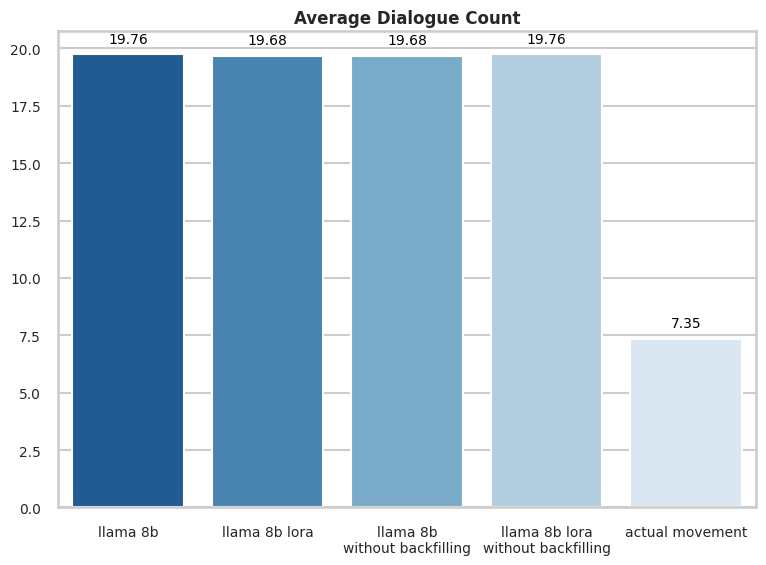

In [92]:
# Average dialogue count plot

import matplotlib.pyplot as plt
import seaborn as sns

values = [llama_8b_average_dialogue_count, llama_8b_lora_average_dialogue_count, llama_8b_without_backfilling_average_dialogue_count, llama_8b_lora_without_backfilling_average_dialogue_count, actual_movement_average_dialogue_count]

labels = ["llama 8b", "llama 8b lora", "llama 8b\nwithout backfilling", "llama 8b lora\nwithout backfilling", "actual movement"]

sns.set_style("whitegrid")  
sns.set_context("talk")

plt.figure(figsize=(8, 6))

ax = sns.barplot(x=labels, y=values, palette="Blues_r")

for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"{v:.2f}", 
            horizontalalignment='center', 
            color='black', 
            fontsize=10)

plt.title("Average Dialogue Count", fontsize=12, fontweight='bold')
# plt.xlabel("Model", fontsize=12)
# plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()


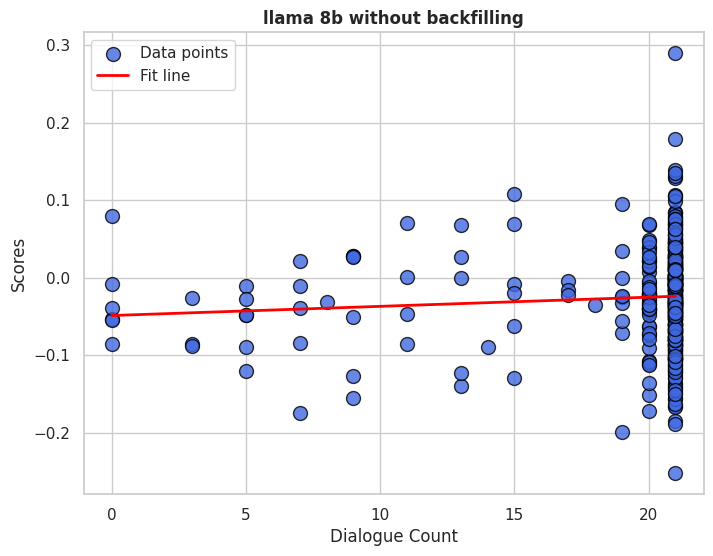

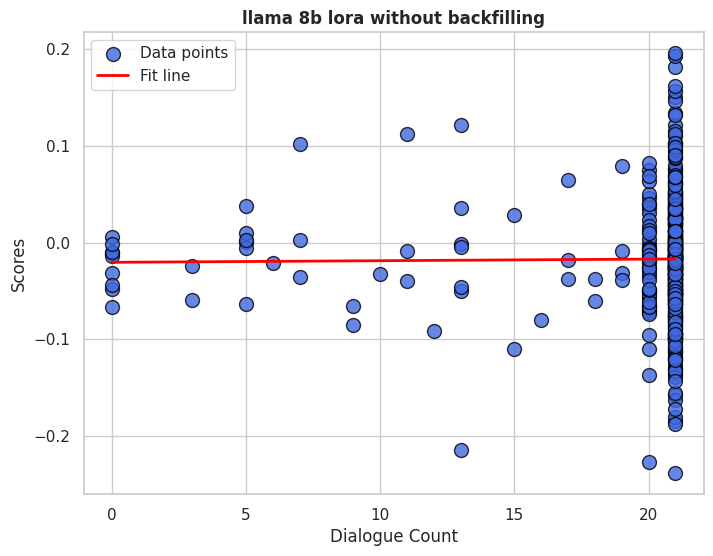

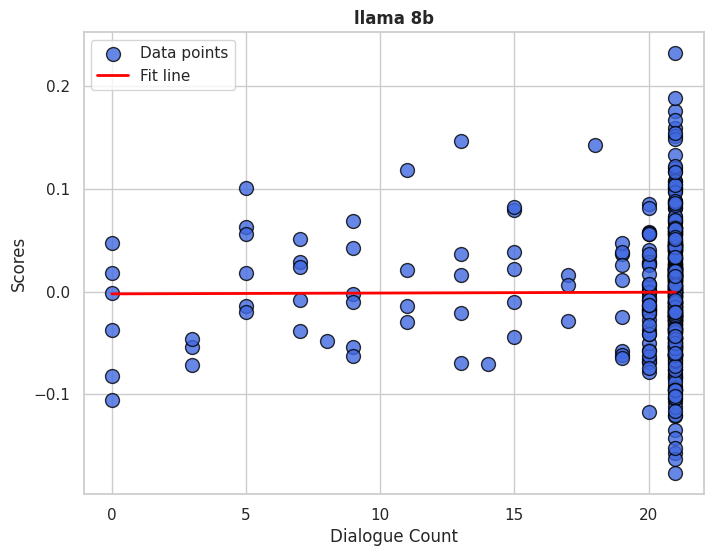

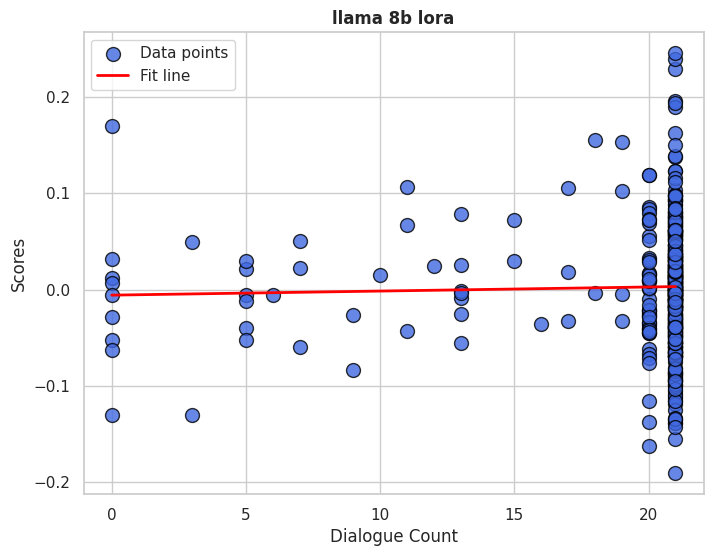

In [96]:
plot_correlation_of_score_and_dialogue_count(llama_8b_without_backfilling_score_list, "llama 8b without backfilling")
plot_correlation_of_score_and_dialogue_count(llama_8b_lora_without_backfilling_score_list, "llama 8b lora without backfilling")
plot_correlation_of_score_and_dialogue_count(llama_8b_score_list, "llama 8b")
plot_correlation_of_score_and_dialogue_count(llama_8b_lora_score_list, "llama 8b lora")

## Explore with/without backfilling actual and prediction ratio

In [31]:
def compute_overlap(actual, predicted):
    """
    计算两个列表的重合度，采用 Jaccard 指数：交集大小 / 并集大小。
    若两者都为空，则认为重合度为 1.
    """
    actual_set = set(actual) if actual else set()
    predicted_set = set(predicted) if predicted else set()
    
    # 如果两者都为空，则认为完全重合
    if not actual_set and not predicted_set:
        return 1.0
    # 如果只有其中一个为空，则重合度为 0
    if not actual_set or not predicted_set:
        return 0.0
    
    intersection = actual_set.intersection(predicted_set)
    union = actual_set.union(predicted_set)
    return len(intersection) / len(union)

def average_overlap_parse_actual(data_list, countries_list):
    overlap_scores = []
    for data in data_list:
        for country in countries_list:
            actual_key = f"{country}_actual_movement"
            predict_key = f"{country}_parse_predict"
            if actual_key in data and predict_key in data:
                # 若值为 None，则设为空列表
                actual_moves = data[actual_key] or []
                predicted_moves = data[predict_key] or []
                score = compute_overlap(actual_moves, predicted_moves)
                overlap_scores.append(score)
    if overlap_scores:
        return sum(overlap_scores) / len(overlap_scores)
    else:
        return None
    
def average_overlap_parse_predict(data_list, countries_list):
    overlap_scores = []
    for data in data_list:
        for country in countries_list:
            origin_predict_key = f"{country}_original_predict"
            predict_key = f"{country}_parse_predict"
            if origin_predict_key in data and predict_key in data:
                # 若值为 None，则设为空列表
                origin_predict_moves = data[origin_predict_key] or ""
                origin_predict_moves = [move.strip() for move in origin_predict_moves.split(';') if move.strip()]
                predicted_moves = data[predict_key] or []
                score = compute_overlap(origin_predict_moves, predicted_moves)
                overlap_scores.append(score)
    if overlap_scores:
        return sum(overlap_scores) / len(overlap_scores)
    else:
        return None

In [32]:
llama_8b_lora_without_backfilling_average_overlap = average_overlap_parse_actual(llama_8b_lora_without_backfilling, countries_list)
llama_8b_without_backfilling_average_overlap = average_overlap_parse_actual(llama_8b_without_backfilling, countries_list)
llama_8b_average_overlap = average_overlap_parse_actual(llama_8b, countries_list)
llama_8b_lora_average_overlap = average_overlap_parse_actual(llama_8b_lora, countries_list)
parse_predict_llama_8b_lora_without_backfilling_average_overlap = average_overlap_parse_predict(llama_8b_lora_without_backfilling, countries_list)
parse_predict_llama_8b_without_backfilling_average_overlap = average_overlap_parse_predict(llama_8b_without_backfilling, countries_list)
parse_predict_llama_8b_average_overlap = average_overlap_parse_predict(llama_8b, countries_list)
parse_predict_llama_8b_lora_average_overlap = average_overlap_parse_predict(llama_8b_lora, countries_list)

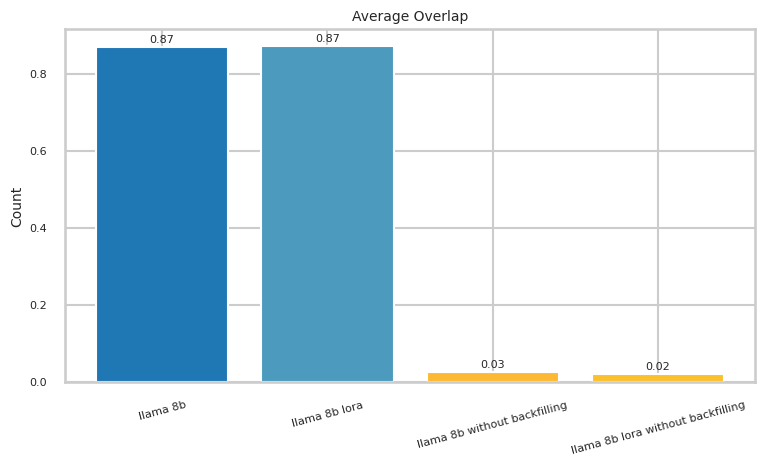

In [28]:
import matplotlib.pyplot as plt

# 数据
labels = ['llama 8b', 
          'llama 8b lora', 
          'llama 8b without backfilling', 
          'llama 8b lora without backfilling']
values = [llama_8b_average_overlap,
          llama_8b_lora_average_overlap,
          llama_8b_without_backfilling_average_overlap,
          llama_8b_lora_without_backfilling_average_overlap]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X 位置：柱子中点
        height + 0.005,                     # Y 位置：稍微高于柱子的顶端
        f'{height:.2f}',                    # 显示的文本
        ha='center',                        # 水平居中
        va='bottom',                        # 垂直对齐在文字的底部
        fontsize=8                          # 将数字字号设置为 8
    )

# 设置标题和坐标轴标签字号
ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
# 如果需要 x 轴标签也可加上
# ax.set_xlabel('X Axis', fontsize=10)

# 调整刻度字体大小
plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

# 让图表更美观
plt.tight_layout()
plt.show()


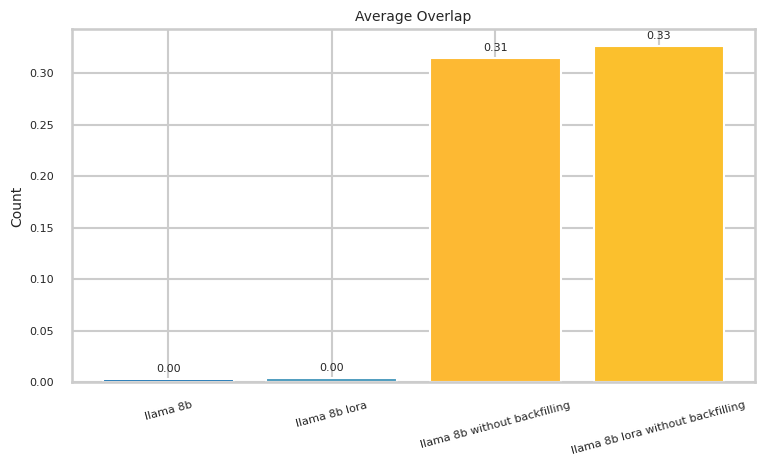

In [33]:
import matplotlib.pyplot as plt

# 数据
labels = ['llama 8b', 
          'llama 8b lora', 
          'llama 8b without backfilling', 
          'llama 8b lora without backfilling']
values = [parse_predict_llama_8b_average_overlap,
          parse_predict_llama_8b_lora_average_overlap,
          parse_predict_llama_8b_without_backfilling_average_overlap,
          parse_predict_llama_8b_lora_without_backfilling_average_overlap]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X 位置：柱子中点
        height + 0.005,                     # Y 位置：稍微高于柱子的顶端
        f'{height:.2f}',                    # 显示的文本
        ha='center',                        # 水平居中
        va='bottom',                        # 垂直对齐在文字的底部
        fontsize=8                          # 将数字字号设置为 8
    )

# 设置标题和坐标轴标签字号
ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
# 如果需要 x 轴标签也可加上
# ax.set_xlabel('X Axis', fontsize=10)

# 调整刻度字体大小
plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

# 让图表更美观
plt.tight_layout()
plt.show()


## Analyse dialogue cut count and score correlation

In [42]:
import os

In [73]:
def traverse_files_with_oswalk(directory):

    file_paths = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            file_paths.append(file_path)
    return file_paths

def read_file(file_paths):
    dict = {}
    for path in file_paths:
        with open(path, 'r') as f:
            data = json.load(f)
            dict[os.path.splitext(os.path.basename(path))[0]] = data
    return dict

def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        # if a['intent_dialogue'] == "":
        #     continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

def average_score(score_list):
    score = 0
    for i in score_list:
        score += i['scores']
    return score / len(score_list)

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)

def method_average_score(score_dict):
    average_score_dict = {}
    for key, value in score_dict.items():
        average_score_dict[key] = average_score(get_score_dict_from_dialogue(value))
    return average_score_dict

In [82]:
llama_8b_lora_negoeval_plus_without_backfilling_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_lora_negoeval_plus_without_backfilling_cut'))
llama_8b_negoeval_plus_without_backfilling_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_negoeval_plus_without_backfilling_cut'))
llama_8b_lora_negoeval_plus_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_lora_negoeval_plus'))
llama_8b_negoeval_plus_cut_dict = read_file(traverse_files_with_oswalk('llama_8b_negoeval_plus'))

In [83]:
llama_8b_lora_negoeval_average_score_without_backfilling = method_average_score(llama_8b_lora_negoeval_plus_without_backfilling_cut_dict)
llama_8b_negoeval_average_score_without_backfilling = method_average_score(llama_8b_negoeval_plus_without_backfilling_cut_dict)
llama_8b_negoeval_average_score = method_average_score(llama_8b_negoeval_plus_cut_dict)
llama_8b_lora_negoeval_average_score = method_average_score(llama_8b_lora_negoeval_plus_cut_dict)

In [84]:
llama_8b_lora_negoeval_average_score, llama_8b_negoeval_average_score, llama_8b_negoeval_average_score_without_backfilling, llama_8b_lora_negoeval_average_score_without_backfilling

({'llama_8b_lora_negoeval_plus_cut_6': 0.007886246582216337,
  'llama_8b_lora_negoeval_plus_cut_4': 0.003418394123736375,
  'llama_8b_lora_negoeval_plus_cut_8': 0.01006290950213099,
  'llama_8b_lora_negoeval_plus_cut_14': 0.00578910298150369,
  'llama_8b_lora_negoeval_plus_cut_10': 0.004956624819897115,
  'llama_8b_lora_negoeval_plus_cut_18': 0.007263867821981208},
 {'llama_8b_negoeval_plus_cut_18': 0.008032543061107168,
  'llama_8b_negoeval_plus_cut_8': 0.008751833227272745,
  'llama_8b_negoeval_plus_cut_4': 0.007791291675703065,
  'llama_8b_negoeval_plus_cut_10': 0.004927190662534614,
  'llama_8b_negoeval_plus_cut_14': 0.008446957803832722,
  'llama_8b_negoeval_plus_cut_6': 0.008375160054280037},
 {'llama_8b_negoeval_plus_without_backfilling_cut_6': -0.01998142879737357,
  'llama_8b_negoeval_plus_without_backfilling_cut_4': -0.02511457016470449,
  'llama_8b_negoeval_plus_without_backfilling_cut_8': -0.020694932730244597,
  'llama_8b_negoeval_plus_without_backfilling_cut_18': -0.02357

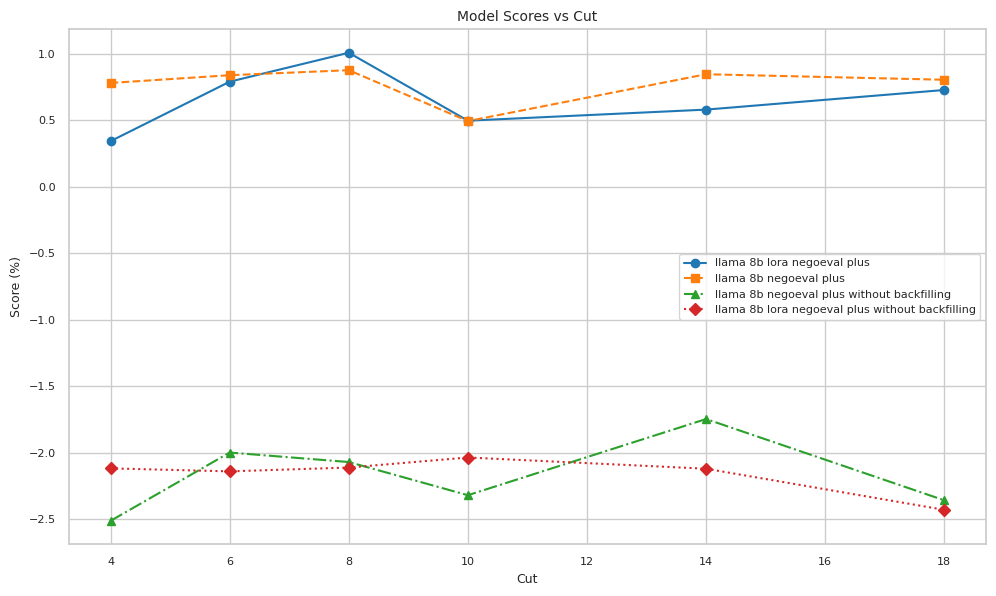

In [97]:
import matplotlib.pyplot as plt

# 全局字体大小设置，也可以针对 axes, legend 分别设置
plt.rcParams.update({
    'font.size': 8,            # 图中所有字体的基本大小
    'axes.titlesize': 10,      # 坐标轴标题的字体大小
    'axes.labelsize': 9,       # 坐标轴刻度标签的字体大小
    'legend.fontsize': 8,      # 图例字体大小
    'xtick.labelsize': 8,      # x 轴刻度文字大小
    'ytick.labelsize': 8       # y 轴刻度文字大小
})

# 假设这四个字典已在前面定义：
# llama_8b_lora_negoeval_average_score = {...}
# llama_8b_negoeval_average_score = {...}
# llama_8b_negoeval_average_score_without_backfilling = {...}
# llama_8b_lora_negoeval_average_score_without_backfilling = {...}

all_data = {
    "llama_8b_lora_negoeval_plus": llama_8b_lora_negoeval_average_score,
    "llama_8b_negoeval_plus": llama_8b_negoeval_average_score,
    "llama_8b_negoeval_plus_without_backfilling": llama_8b_negoeval_average_score_without_backfilling,
    "llama_8b_lora_negoeval_plus_without_backfilling": llama_8b_lora_negoeval_average_score_without_backfilling
}

plt.figure(figsize=(10, 6))

# 定义不同的点形状与线型
markers = ['o', 's', '^', 'D']        # 圆形, 方形, 三角形, 菱形
linestyles = ['-', '--', '-.', ':']   # 实线, 虚线, 点划线, 点线
# 也可以使用 matplotlib 提供的内置颜色循环，或手动指定颜色
colors = plt.cm.tab10(range(len(all_data)))  # 从 tab10 调色板中选取

for (model_name, model_data), marker, ls, color in zip(all_data.items(), markers, linestyles, colors):
    cuts = []
    scores = []
    for key, val in model_data.items():
        cut_num = int(key.split('_cut_')[-1])
        cuts.append(cut_num)
        scores.append(val * 100)  # 转为百分比

    # 按 cut 从小到大排序
    sorted_pairs = sorted(zip(cuts, scores), key=lambda x: x[0])
    sorted_cuts, sorted_scores = zip(*sorted_pairs)

    # 去掉下划线（替换为空格）并绘制
    label_name = model_name.replace('_', ' ')
    plt.plot(
        sorted_cuts, 
        sorted_scores, 
        marker=marker,       # 设置点形状
        linestyle=ls,        # 设置线型
        color=color,         # 设置颜色
        markersize=6,        # 可调整点的大小
        linewidth=1.5,       # 可调整线条粗细
        label=label_name
    )

plt.xlabel('Cut')
plt.ylabel('Score (%)')
plt.title('Model Scores vs Cut')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [99]:
import rich

In [102]:
rich.print(llama_8b_without_backfilling[1])

{
    'game_id': '38101',
    'phase_name': 'F1903M',
    'env_uuid': '01JN071DSNTS2AM1HYSHS0NSHG',
    'England_original_predict': '',
    'France_original_predict': 'A MAR BUR; A PIC BEL',
    'England_units': None,
    'France_units': None,
    'intent_dialogue': "0 ENGLAND -> FRANCE: I agree that moving to Hel is key to breaking this stalemate. I’ll 
make sure to support your plan to Ruhr. But let’s also keep an eye on Russia, he’s still a wild card in this game. 
Have you heard anything from Italy?\n1 FRANCE -> ENGLAND: I think we should push for a stronger presence in Ruhr, 
maybe we can even convince Italy to join us in a coordinated attack. What are your thoughts on that?\n2 ENGLAND -> 
FRANCE: I think it's a great idea to push for a stronger presence in Ruhr, but we should be cautious not to provoke
Italy into joining Russia. Let's also keep in mind our own army movements, I'm thinking of moving my army from Hol 
to Bur to support your plan, what do you think?\n3 FRANCE -> ENGLAND: I'm glad you're on board with supporting my 
move into Ruhr. However, I'm still a bit concerned about Russia's position. Do you think we should consider a 
possible attack on Russia in the future to prevent them from getting too strong?\n4 ENGLAND -> FRANCE: I think we 
should focus on supporting your move into Ruhr this turn. If we can hold Ruhr, it'll give us a strong bargaining 
chip for future negotiations. What do you think about Italy's position, are you considering any moves to counter 
their potential threat?\n5 FRANCE -> ENGLAND: I think we should also consider supporting your move into Belgium, it
would be a great way to put pressure on Germany and make it harder for them to support Austria. What do you 
think?\n6 ENGLAND -> FRANCE: I've been thinking, if we can get a foothold in Belgium, it would be a great way to 
put pressure on Germany and make it harder for them to support Austria. What do you think about moving my army from
Nth to Hol?\n7 FRANCE -> ENGLAND: I think we should also support Italy's potential move into the Mediterranean, it 
could give us a strategic advantage and make it harder for Austria to hold on to Italy. What do you think?\n8 
ENGLAND -> FRANCE: I think it's time we discussed Italy's potential move into the Mediterranean. What's your take 
on that? Should we try to coordinate with them or keep our distance?\n9 FRANCE -> ENGLAND: That sounds like a great
plan, but we should also be cautious not to give Russia an opportunity to attack us in the north. What are your 
thoughts on supporting my army in Mar to prepare for a potential attack on Italy?\n10 ENGLAND -> FRANCE: I think we
should focus on consolidating our gains in Belgium and Ruhr. Let's make sure our armies are in position to support 
each other. What are your thoughts on the best way to coordinate our moves in the next turn?\n11 FRANCE -> ENGLAND:
I agree that moving to Hel is key to breaking this stalemate. Let's focus on supporting each other's moves and 
putting pressure on Germany. What do you think about supporting my move into Ruhr this turn?\n12 ENGLAND -> FRANCE:
I think we should consider moving my army from Nth to Hol this turn, to support your plan to Ruhr and put pressure 
on Germany. What do you think?\n13 FRANCE -> ENGLAND: I'm happy to support your move into Ruhr, but I'm still 
concerned about Russia's position. Have you considered the possibility of Italy joining forces with Russia, and if 
so, how do you plan to counter that?\n14 ENGLAND -> FRANCE: I agree with your assessment of Italy's potential 
threat. Let's discuss possible moves to counter their influence in the Mediterranean. What are your thoughts on 
supporting my army in Nth to Hol?\n15 FRANCE -> ENGLAND: That's a great idea. Supporting Italy's potential move 
into the Mediterranean could be a game-changer. But we should also keep an eye on Russia, they're still a wild card
in this game. Have you considered any moves to counter their potential threat?\n16 ENGLAND -> FRA

In [103]:
rich.print("0 ENGLAND -> GERMANY: Ah, Germany, my old friend. I see you're planning to move some of your armies this turn. I was wondering if we could discuss the details of your plans. Perhaps we could find a mutually beneficial arrangement? I'm looking to secure my position in the North Sea, and I'm open to suggestions on how to do so without, ah, antagonizing you.\n1 GERMANY -> ENGLAND: England, my friend, I'm glad you're interested in discussing our plans. As you know, I'm looking to secure my position in the North Sea, and I believe our interests align in this regard. However, I do have some concerns about your plans to move your fleets in the North Sea. How do you plan to ensure that your movements won't put pressure on my position in Denmark?\n2 ENGLAND -> GERMANY: I understand your concerns, Germany. However, I'm not planning to move my fleets in a way that would put pressure on your position in Denmark. In fact, I'm considering moving my fleet in the North Sea to support your position in the Baltic Sea. I believe this could be a win-win situation for both of us. What are your thoughts on this proposal?\n3 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I do have some concerns about your fleet in the North Sea. If you do move it to support me, how do you plan to ensure that our fleets won't be at risk of being attacked by the Russian or Italian fleets?\n4 ENGLAND -> GERMANY: I see you're planning to move your army from Kiel to Denmark. If you do, I'd like to propose a deal: you move your army from Kiel to Denmark, and in return, I'll make sure to support you in the Baltic Sea by not moving my fleet in the North Sea. This way, we both secure our positions and avoid any potential conflicts. What are your thoughts on this proposal?\n5 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I'm not sure I'm comfortable with moving my army from Kiel to Denmark just yet. Could you tell me more about why you think it's in our mutual interest to make this move?\n6 ENGLAND -> GERMANY: I understand your concerns, Germany. However, I'd like to propose an alternative solution. Why don't we discuss the possibility of you moving your army from Kiel to Hamburg instead? That way, you can still secure your position in Denmark, and I can focus on supporting your position in the Baltic Sea without putting pressure on your Danish army.\n7 GERMANY -> ENGLAND: I appreciate your willingness to consider alternative solutions, England. However, I'm not sure moving my army from Kiel to Hamburg would be beneficial to our mutual interests. Could you explain why you think this move would be advantageous for both of us?\n8 ENGLAND -> GERMANY: I see you're considering moving your army from Kiel to Hamburg. I think that's a good idea, but I'd like to propose an additional move to further secure our mutual interests. Why don't you move your army from Munich to Austria, and I'll make sure to support you in the Baltic Sea by not moving my fleet in the North Sea? This way, we both gain a strategic advantage and avoid any potential conflicts.\n9 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I'm still hesitant to move my army from Kiel to Hamburg. Can you provide more information on how your proposed move would help me secure my position in Denmark and the Baltic Sea?\n10 ENGLAND -> GERMANY: I see you're considering moving your army from Kiel to Hamburg, Germany. I think that's a good idea, but I'd like to propose an additional move to further secure our mutual interests. Why don't you move your army from Munich to Austria, and I'll make sure to support you in the Baltic Sea by not moving my fleet in the North Sea? This way, we both gain a strategic advantage and avoid any potential conflicts.\n11 GERMANY -> ENGLAND: I'm glad we're having this discussion, England. However, I still have some doubts about your proposal. Could you explain how you plan to prevent Russia from moving their fleet to the North Sea if your fleet is stationed in the Baltic Sea?\n12 ENGLAND -> GERMANY: Germany, I understand your concerns about Russia moving their fleet to the North Sea. I was thinking that if you move your army from Kiel to Hamburg, it would be more difficult for Russia to move their fleet into the Baltic Sea, giving us both more time to respond to any potential threats. What are your thoughts on this?\n13 GERMANY -> ENGLAND: I appreciate your creative proposal, England, but I'm afraid I'm still not convinced that moving my army from Kiel to Hamburg is the best move for us both. Can you tell me how you plan to ensure that Italy won't try to take advantage of the situation and move their fleet to the North Sea, potentially putting pressure on our positions?\n14 ENGLAND -> GERMANY: Germany, I think we've discussed the potential moves in the Baltic Sea and the North Sea at length. I'd like to propose a new direction for our negotiations. What are your thoughts on a possible alliance between England and Germany in the near future?\n15 GERMANY -> ENGLAND: I appreciate your willingness to consider an alliance, England. However, I'm not sure that's something we should discuss at this point. As you know, our positions in the North Sea and the Baltic Sea are still quite fluid. I'd like to focus on securing our positions there first before we start talking about long-term alliances. Can we table this discussion for now and focus on making some moves that will benefit both of us in the short term? I'm still not convinced that moving my army from Kiel to Hamburg is the best move for us both. Can you tell me more about why you think it's in our mutual interest to make this move?\n16 ENGLAND -> GERMANY: I think we've been discussing this for a while, Germany. I'd like to propose a compromise. Why don't you move your army from Kiel to Hamburg, and I'll move my fleet in the North Sea to support your position in the Baltic Sea? This way, we both gain a strategic advantage without putting pressure on each other's positions.\n17 GERMANY -> ENGLAND: I understand that you're trying to secure our mutual interests, England. However, I still have some doubts about the potential consequences of moving my army from Kiel to Hamburg. Could you provide more concrete assurances that this move won't put us at a disadvantage in the long term?\n18 ENGLAND -> GERMANY: Germany, I think I've made my position clear, but I'd like to reiterate the importance of securing our mutual interests. If you move your army from Kiel to Hamburg, I'll ensure that my fleet in the North Sea doesn't pose a threat to your position in the Baltic Sea.\n19 GERMANY -> ENGLAND: I'm starting to think that we're getting bogged down in details, England. Can we take a step back and consider the bigger picture? What are your long-term goals for England, and how do you see our alliance fitting into that?\n20 ENGLAND -> GERMANY: Germany, I think we've been discussing this for a while. I'd like to propose a final compromise. Why don't you move your army from Kiel to Hamburg, and I'll move my fleet in the North Sea to support your position in the Baltic Sea? I'm willing to take a risk to secure our mutual interests and gain a strategic advantage. What are your thoughts on this final proposal?",)

0 ENGLAND -> GERMANY: Ah, Germany, my old friend. I see you're planning to move some of your armies this turn. I 
was wondering if we could discuss the details of your plans. Perhaps we could find a mutually beneficial 
arrangement? I'm looking to secure my position in the North Sea, and I'm open to suggestions on how to do so 
without, ah, antagonizing you.
1 GERMANY -> ENGLAND: England, my friend, I'm glad you're interested in discussing our plans. As you know, I'm 
looking to secure my position in the North Sea, and I believe our interests align in this regard. However, I do 
have some concerns about your plans to move your fleets in the North Sea. How do you plan to ensure that your 
movements won't put pressure on my position in Denmark?
2 ENGLAND -> GERMANY: I understand your concerns, Germany. However, I'm not planning to move my fleets in a way 
that would put pressure on your position in Denmark. In fact, I'm considering moving my fleet in the North Sea to 
support your position in the Baltic Sea. I believe this could be a win-win situation for both of us. What are your 
thoughts on this proposal?
3 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I 
do have some concerns about your fleet in the North Sea. If you do move it to support me, how do you plan to ensure
that our fleets won't be at risk of being attacked by the Russian or Italian fleets?
4 ENGLAND -> GERMANY: I see you're planning to move your army from Kiel to Denmark. If you do, I'd like to propose 
a deal: you move your army from Kiel to Denmark, and in return, I'll make sure to support you in the Baltic Sea by 
not moving my fleet in the North Sea. This way, we both secure our positions and avoid any potential conflicts. 
What are your thoughts on this proposal?
5 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I'm
not sure I'm comfortable with moving my army from Kiel to Denmark just yet. Could you tell me more about why you 
think it's in our mutual interest to make this move?
6 ENGLAND -> GERMANY: I understand your concerns, Germany. However, I'd like to propose an alternative solution. 
Why don't we discuss the possibility of you moving your army from Kiel to Hamburg instead? That way, you can still 
secure your position in Denmark, and I can focus on supporting your position in the Baltic Sea without putting 
pressure on your Danish army.
7 GERMANY -> ENGLAND: I appreciate your willingness to consider alternative solutions, England. However, I'm not 
sure moving my army from Kiel to Hamburg would be beneficial to our mutual interests. Could you explain why you 
think this move would be advantageous for both of us?
8 ENGLAND -> GERMANY: I see you're considering moving your army from Kiel to Hamburg. I think that's a good idea, 
but I'd like to propose an additional move to further secure our mutual interests. Why don't you move your army 
from Munich to Austria, and I'll make sure to support you in the Baltic Sea by not moving my fleet in the North 
Sea? This way, we both gain a strategic advantage and avoid any potential conflicts.
9 GERMANY -> ENGLAND: I appreciate your willingness to support my position in the Baltic Sea, England. However, I'm
still hesitant to move my army from Kiel to Hamburg. Can you provide more information on how your proposed move 
would help me secure my position in Denmark and the Baltic Sea?
10 ENGLAND -> GERMANY: I see you're considering moving your army from Kiel to Hamburg, Germany. I think that's a 
good idea, but I'd like to propose an additional move to further secure our mutual interests. Why don't you move 
your army from Munich to Austria, and I'll make sure to support you in the Baltic Sea by not moving my fleet in the
North Sea? This way, we both gain a strategic advantage and avoid any potential conflicts.
11 GERMANY -> ENGLAND: I'm glad we're having this discussion, England. However, I st